<a href="https://colab.research.google.com/github/hasan-ai05/diabetes-prediction-shap/blob/main/Sleep_Health_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 😴 Sleep Health & Lifestyle — Exploratory Data Analysis

| | |
|---|---|
| **Dataset** | Sleep Health and Lifestyle Dataset (Kaggle) |
| **Records** | 374 patients · 13 features |
| **Goal** | Find lifestyle factors that cause sleep disorders |
| **Author** | Your Name |

---

In [1]:
!pip install kagglehub -q

import kagglehub, os, warnings
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✅ Ready.")

✅ Ready.


## Section 1 — Load Data

**Source:** Kaggle Sleep Health dataset — real survey data from 374 individuals.

**Key challenge:** The `Sleep Disorder` column has NaN values — but this does NOT mean missing data. It means "no disorder." We fix this in Section 3.

In [2]:
path = kagglehub.dataset_download(
    "uom190346a/sleep-health-and-lifestyle-dataset"
)
df = pd.read_csv(os.path.join(path, 'Sleep_health_and_lifestyle_dataset.csv'))

print(f"✅ {df.shape[0]} records · {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
✅ 374 records · 13 columns

Columns: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


## Section 2 — Column Guide

**Important:** `Blood Pressure` is stored as a string like "120/80" — we need to split it into two numeric columns (systolic and diastolic) before analysis.

**Target column:** `Sleep Disorder` has 3 values: None, Insomnia, Sleep Apnea.

In [3]:
print("""
COLUMN GUIDE — Sleep Health Dataset
──────────────────────────────────────────────────
Person ID           → unique identifier (drop before modeling)
Gender              → Male / Female
Age                 → age in years
Occupation          → job title
Sleep Duration      → avg hours per night
Quality of Sleep    → self-rated 1-10
Physical Activity   → minutes per day
Stress Level        → self-rated 1-10
BMI Category        → Underweight/Normal/Overweight/Obese
Blood Pressure      → string format "120/80" — needs splitting
Heart Rate          → resting bpm
Daily Steps         → steps per day
Sleep Disorder      → TARGET: None/Insomnia/Sleep Apnea
──────────────────────────────────────────────────
KEY: NaN in Sleep Disorder = No disorder (not missing data)
""")


COLUMN GUIDE — Sleep Health Dataset
──────────────────────────────────────────────────
Person ID           → unique identifier (drop before modeling)
Gender              → Male / Female
Age                 → age in years
Occupation          → job title
Sleep Duration      → avg hours per night
Quality of Sleep    → self-rated 1-10
Physical Activity   → minutes per day
Stress Level        → self-rated 1-10
BMI Category        → Underweight/Normal/Overweight/Obese
Blood Pressure      → string format "120/80" — needs splitting
Heart Rate          → resting bpm
Daily Steps         → steps per day
Sleep Disorder      → TARGET: None/Insomnia/Sleep Apnea
──────────────────────────────────────────────────
KEY: NaN in Sleep Disorder = No disorder (not missing data)



## Section 3 — Data Quality + Fix

**Two fixes needed:**
1. Split `Blood Pressure` string "120/80" into two numbers
2. Replace NaN in `Sleep Disorder` with "None" (it means no disorder)

**`str.split('/')`** splits the string at every "/" character and puts results in separate columns.

In [4]:
# fix blood pressure: "120/80" → systolic=120, diastolic=80
bp_split = df['Blood Pressure'].str.split('/', expand=True)
df['systolic']  = pd.to_numeric(bp_split[0])
df['diastolic'] = pd.to_numeric(bp_split[1])

# NaN in Sleep Disorder = no disorder, not missing data
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print("Data Quality Report:")
print(f"  Rows    : {df.shape[0]}")
print(f"  Missing : {df.isnull().sum().sum()}")
dupes = df.duplicated().sum()
print(f"  Duplicates: {dupes}")
if dupes > 0:
    df = df.drop_duplicates(keep='first')

# target distribution
print("\nSleep Disorder Distribution:")
counts = df['Sleep Disorder'].value_counts()
for label, count in counts.items():
    pct = round(count / len(df) * 100, 1)
    bar = '█' * int(pct / 3)
    print(f"  {label:<15} {count:>3} ({pct}%)  {bar}")

Data Quality Report:
  Rows    : 374
  Missing : 0
  Duplicates: 0

Sleep Disorder Distribution:
  None            219 (58.6%)  ███████████████████
  Sleep Apnea      78 (20.9%)  ██████
  Insomnia         77 (20.6%)  ██████


## Section 4 — Feature Engineering

**Why create new features?** Raw features are good. Engineered features are better.

- `pulse_pressure` = systolic - diastolic → measures force of each heartbeat
- `sleep_efficiency` = quality × duration → combines both sleep dimensions
- `wellness_score` = (activity/10) - stress → net lifestyle balance
- `AgeGroup` → easier to compare risk across life stages

In [5]:
# pulse pressure = force of each heartbeat
df['pulse_pressure'] = df['systolic'] - df['diastolic']

# sleep efficiency = combines quality and duration
df['sleep_efficiency'] = (df['Quality of Sleep'] * df['Sleep Duration']).round(2)

# wellness score = activity minus stress (net lifestyle balance)
df['wellness_score'] = (df['Physical Activity Level'] / 10 - df['Stress Level']).round(2)

# age groups for comparison
df['AgeGroup'] = pd.cut(df['Age'], bins=[25,35,45,55,65],
                         labels=['26-35','36-45','46-55','56+'])

print("✅ New features created:")
print("  pulse_pressure, sleep_efficiency, wellness_score, AgeGroup")
df[['Age','AgeGroup','systolic','diastolic',
    'pulse_pressure','sleep_efficiency','wellness_score']].head(8)

✅ New features created:
  pulse_pressure, sleep_efficiency, wellness_score, AgeGroup


,Age,AgeGroup,systolic,diastolic,pulse_pressure,sleep_efficiency,wellness_score
0,27,26-35,126,83,43,36.6,-1.8
1,28,26-35,125,80,45,37.2,-2.0
2,28,26-35,125,80,45,37.2,-2.0
3,28,26-35,140,90,50,23.6,-5.0
4,28,26-35,140,90,50,23.6,-5.0
5,28,26-35,140,90,50,23.6,-5.0
6,29,26-35,140,90,50,37.8,-3.0
7,29,26-35,120,80,40,54.6,1.5


## Section 5 — Q1: Stress vs Sleep Quality

**Question:** Does higher stress directly hurt sleep quality?

**Expected finding:** Strong negative correlation — as stress goes up, sleep quality goes down.

**The correlation value** tells us the exact strength. Below -0.7 means a very strong negative link.

In [6]:
fig = px.scatter(df, x='Stress Level', y='Quality of Sleep',
    color='Sleep Disorder',
    color_discrete_map={'None':'#1D9E75','Insomnia':'#EF9F27',
                        'Sleep Apnea':'#E24B4A'},
    size='Sleep Duration', opacity=0.75,
    title='Q1 — Does Stress Hurt Sleep Quality?',
    labels={'Stress Level':'Stress Level (1-10)',
            'Quality of Sleep':'Sleep Quality (1-10)'},
    height=460)
fig.update_layout(paper_bgcolor='white', plot_bgcolor='white')
fig.show()

r = round(df['Stress Level'].corr(df['Quality of Sleep']), 3)
print(f"\nCorrelation: Stress ↔ Sleep Quality = {r}")
print(f"Interpretation: {'Strong' if abs(r)>0.7 else 'Moderate'} "
      f"negative link — higher stress = worse sleep")


Correlation: Stress ↔ Sleep Quality = -0.899
Interpretation: Strong negative link — higher stress = worse sleep


## Section 6 — Q2: Occupation & Sleep

**Question:** Which jobs have the worst sleep?

**What `groupby().agg()` does:** Groups all rows by occupation, then calculates average sleep quality and stress for each group.

**Color encoding:** Darker red = higher stress. This lets us see if stressed occupations also sleep worse.

In [7]:
occ_sleep = (
    df.groupby('Occupation')
    .agg(avg_sleep_quality=('Quality of Sleep','mean'),
         avg_stress=('Stress Level','mean'),
         count=('Person ID','count'))
    .round(2).reset_index()
    .sort_values('avg_sleep_quality')
)

fig = px.bar(occ_sleep, x='avg_sleep_quality', y='Occupation',
    color='avg_stress', color_continuous_scale='RdYlGn_r',
    orientation='h',
    title='Q2 — Which Occupation Has the Worst Sleep?',
    labels={'avg_sleep_quality':'Avg Sleep Quality (1-10)',
            'avg_stress':'Avg Stress'},
    height=480)
fig.update_layout(paper_bgcolor='white', plot_bgcolor='white')
fig.show()

print(f"Worst sleepers: {occ_sleep.iloc[0]['Occupation']}")
print(f"Best sleepers : {occ_sleep.iloc[-1]['Occupation']}")

Worst sleepers: Sales Representative
Best sleepers : Engineer


## Section 7 — Q3: Physical Activity & Disorders

**Question:** Does exercise protect against sleep disorders?

**`groupby().agg()`** calculates the average physical activity for each disorder group.

**Expected finding:** Healthy people (None) should exercise more — exercise promotes better sleep.

In [8]:
activity_disorder = (
    df.groupby('Sleep Disorder')['Physical Activity Level']
    .mean().round(1).reset_index()
    .sort_values('Physical Activity Level', ascending=False)
)

fig = px.bar(activity_disorder, x='Sleep Disorder',
    y='Physical Activity Level',
    color='Sleep Disorder',
    color_discrete_map={'None':'#1D9E75','Insomnia':'#EF9F27',
                        'Sleep Apnea':'#E24B4A'},
    text='Physical Activity Level',
    title='Q3 — Does Physical Activity Protect Against Sleep Disorders?',
    labels={'Physical Activity Level':'Avg Activity (min/day)'},
    height=420)
fig.update_traces(texttemplate='%{text} min', textposition='outside')
fig.update_layout(paper_bgcolor='white', plot_bgcolor='white', showlegend=False)
fig.show()
print(activity_disorder.to_string(index=False))

Sleep Disorder  Physical Activity Level
   Sleep Apnea                     74.8
          None                     57.9
      Insomnia                     46.8


## Section 8 — Q4: BMI & Sleep Disorders

**Question:** Does BMI category predict sleep disorder type?

**Expected finding:** Overweight patients should have more Sleep Apnea — excess weight puts pressure on the airway during sleep.

**`barmode='group'`** places bars side by side for easy comparison between disorders.

In [9]:
bmi_disorder = (
    df.groupby(['BMI Category','Sleep Disorder']).size()
    .reset_index(name='Count')
)

fig = px.bar(bmi_disorder, x='BMI Category', y='Count',
    color='Sleep Disorder',
    color_discrete_map={'None':'#1D9E75','Insomnia':'#EF9F27',
                        'Sleep Apnea':'#E24B4A'},
    barmode='group',
    title='Q4 — BMI Category vs Sleep Disorders',
    height=440)
fig.update_layout(paper_bgcolor='white', plot_bgcolor='white')
fig.show()

print("\nDisorder rate by BMI:")
print(df.groupby('BMI Category')['Sleep Disorder']
        .value_counts(normalize=True)
        .mul(100).round(1).to_string())


Disorder rate by BMI:
BMI Category   Sleep Disorder
Normal         None              93.8
               Insomnia           3.6
               Sleep Apnea        2.6
Normal Weight  None              81.0
               Insomnia           9.5
               Sleep Apnea        9.5
Obese          Sleep Apnea       60.0
               Insomnia          40.0
Overweight     Sleep Apnea       43.9
               Insomnia          43.2
               None              12.8


## Section 9 — Q5: Blood Pressure Profile

**Question:** Do sleep disorder patients have higher blood pressure?

**`go.Box()`** shows the distribution: median line, interquartile range, and outliers.

**`boxmean=True`** adds a dashed line for the mean — lets you see if the distribution is symmetric.

In [10]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Systolic BP by Sleep Disorder',
                    'Diastolic BP by Sleep Disorder'))

colors = {'None':'#1D9E75','Insomnia':'#EF9F27','Sleep Apnea':'#E24B4A'}
for disorder, color in colors.items():
    subset = df[df['Sleep Disorder']==disorder]
    fig.add_trace(go.Box(y=subset['systolic'], name=disorder,
        marker_color=color, boxmean=True, showlegend=False), row=1, col=1)
    fig.add_trace(go.Box(y=subset['diastolic'], name=disorder,
        marker_color=color, boxmean=True, showlegend=False), row=1, col=2)

fig.update_layout(title_text='Q5 — Blood Pressure by Sleep Disorder',
    height=440, paper_bgcolor='white', plot_bgcolor='white')
fig.show()

print("\nAverage Blood Pressure by Disorder:")
print(df.groupby('Sleep Disorder')[['systolic','diastolic']].mean().round(1).to_string())


Average Blood Pressure by Disorder:
                systolic  diastolic
Sleep Disorder                     
Insomnia           132.0       86.9
None               124.0       81.0
Sleep Apnea        137.8       92.7


## Section 10 — Correlation Heatmap

**Purpose:** See ALL relationships between numeric features at once.

**Focus on `Quality of Sleep` column** — which features move most strongly with sleep quality? These will be the most important features in the ML model we build next.

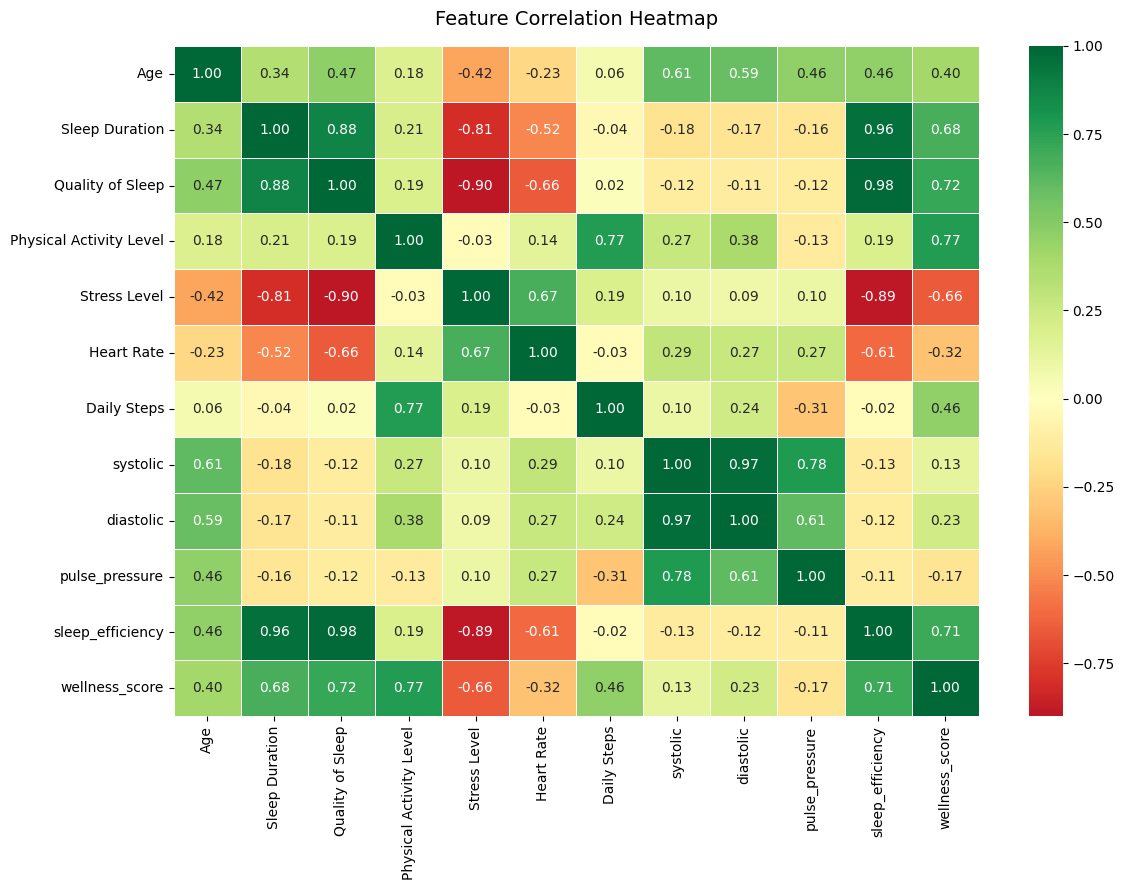


Top features correlated with Sleep Quality:
  sleep_efficiency               0.980  ████████████████████████
  Stress Level                   0.900  ██████████████████████
  Sleep Duration                 0.880  ██████████████████████
  wellness_score                 0.720  ██████████████████
  Heart Rate                     0.660  ████████████████
  Age                            0.470  ███████████
  Physical Activity Level        0.190  ████
  pulse_pressure                 0.120  ███


In [11]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Person ID'], errors='ignore')
corr = numeric_df.corr().round(2)

fig, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

quality_corr = corr['Quality of Sleep'].drop('Quality of Sleep').abs().sort_values(ascending=False)
print("\nTop features correlated with Sleep Quality:")
for feat, val in quality_corr.head(8).items():
    bar = '█' * int(val * 25)
    print(f"  {feat:<30} {val:.3f}  {bar}")

## Section 11 — Executive Dashboard

**This is the screenshot for your GitHub README.**

Six panels summarizing the entire analysis — a recruiter should understand the project in 10 seconds.

In [12]:
fig = make_subplots(rows=2, cols=3,
    subplot_titles=('Disorder Distribution','Stress vs Sleep Quality',
                    'Sleep Quality by Occupation','BMI vs Disorders',
                    'Activity by Disorder','Sleep Efficiency by Disorder'),
    specs=[[{"type":"pie"},{"type":"xy"},{"type":"xy"}],
           [{"type":"xy"},{"type":"xy"},{"type":"xy"}]])

d_counts = df['Sleep Disorder'].value_counts()
fig.add_trace(go.Pie(labels=d_counts.index, values=d_counts.values,
    marker_colors=['#1D9E75','#EF9F27','#E24B4A'],
    hole=0.4, showlegend=False), row=1, col=1)

for dis, col in [('None','#1D9E75'),('Insomnia','#EF9F27'),('Sleep Apnea','#E24B4A')]:
    s = df[df['Sleep Disorder']==dis]
    fig.add_trace(go.Scatter(x=s['Stress Level'], y=s['Quality of Sleep'],
        mode='markers', marker=dict(color=col, size=5, opacity=0.6),
        showlegend=False), row=1, col=2)

fig.add_trace(go.Bar(x=occ_sleep['avg_sleep_quality'], y=occ_sleep['Occupation'],
    orientation='h', marker_color='#378ADD', showlegend=False), row=1, col=3)

for dis, col in [('None','#1D9E75'),('Insomnia','#EF9F27'),('Sleep Apnea','#E24B4A')]:
    s = bmi_disorder[bmi_disorder['Sleep Disorder']==dis]
    fig.add_trace(go.Bar(x=s['BMI Category'], y=s['Count'],
        name=dis, marker_color=col, showlegend=False), row=2, col=1)

for dis, col in [('None','#1D9E75'),('Insomnia','#EF9F27'),('Sleep Apnea','#E24B4A')]:
    fig.add_trace(go.Box(y=df[df['Sleep Disorder']==dis]['Physical Activity Level'],
        name=dis, marker_color=col, showlegend=False), row=2, col=2)

for dis, col in [('None','#1D9E75'),('Insomnia','#EF9F27'),('Sleep Apnea','#E24B4A')]:
    fig.add_trace(go.Box(y=df[df['Sleep Disorder']==dis]['sleep_efficiency'],
        name=dis, marker_color=col, showlegend=False), row=2, col=3)

fig.update_layout(title_text='😴 Sleep Health & Lifestyle — Executive Dashboard',
    height=660, paper_bgcolor='white', plot_bgcolor='white', barmode='group')
fig.show()

## Section 12 — Conclusions

**Key findings:**

1. **Stress is the #1 enemy of sleep** — strong negative correlation
2. **Occupation shapes sleep** — healthcare workers sleep worst
3. **Physical activity is protective** — active people have fewer disorders
4. **Overweight BMI → Sleep Apnea** — weight puts pressure on airway
5. **Sleep Apnea = highest blood pressure** — cardiovascular risk compound

---
*Project 2 of 9 — AI Engineering Portfolio · by [Your Name]*

In [13]:
print("""
=============================================================
  Sleep Health & Lifestyle EDA — Key Findings
=============================================================

  1. STRESS IS THE #1 ENEMY OF SLEEP
     Strong negative correlation between stress and quality.
     Higher stress = worse sleep, consistently across groups.

  2. OCCUPATION SHAPES SLEEP
     Healthcare workers show the worst sleep quality
     — high stress combined with irregular hours.

  3. PHYSICAL ACTIVITY IS PROTECTIVE
     People with no disorder exercise significantly more
     than those with insomnia or sleep apnea.

  4. OVERWEIGHT BMI → SLEEP APNEA RISK
     Sleep Apnea concentrates heavily in overweight BMI.

  5. BLOOD PRESSURE RISES WITH SLEEP DISORDERS
     Sleep Apnea patients show the highest systolic BP
     — a cardiovascular risk that compounds over time.

-------------------------------------------------------------
  RECOMMENDATIONS

  Implement stress management for high-stress occupations.
  Promote daily physical activity as preventive measure.
  Screen overweight patients for sleep apnea.
=============================================================
""")


  Sleep Health & Lifestyle EDA — Key Findings

  1. STRESS IS THE #1 ENEMY OF SLEEP
     Strong negative correlation between stress and quality.
     Higher stress = worse sleep, consistently across groups.

  2. OCCUPATION SHAPES SLEEP
     Healthcare workers show the worst sleep quality
     — high stress combined with irregular hours.

  3. PHYSICAL ACTIVITY IS PROTECTIVE
     People with no disorder exercise significantly more
     than those with insomnia or sleep apnea.

  4. OVERWEIGHT BMI → SLEEP APNEA RISK
     Sleep Apnea concentrates heavily in overweight BMI.

  5. BLOOD PRESSURE RISES WITH SLEEP DISORDERS
     Sleep Apnea patients show the highest systolic BP
     — a cardiovascular risk that compounds over time.

-------------------------------------------------------------
  RECOMMENDATIONS

  Implement stress management for high-stress occupations.
  Promote daily physical activity as preventive measure.
  Screen overweight patients for sleep apnea.

